<a href="https://colab.research.google.com/github/Alanoud-Alotaibi/Data-Quality-Monitoring-PoC/blob/main/Clinic_Appointments_DataQuality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##-DOWNLOAD DATASET AND LIBRARIES

In [ ]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt

path = kagglehub.dataset_download("nudratabbas/messy-clinic-appointments-dataset")
file_path = os.path.join(path, 'messy_clinic_appointments.csv')
df = pd.read_csv(file_path)

##-SHAPE OF DATASET

In [13]:
# shape of dataset
print(df.columns)
num_records = df.shape[0]
num_attributes = df.shape[1]
print(f"\nThe Dataset has {num_attributes} attributes, {num_records} instances.")

Index(['patient_id', 'patient_name', 'age', 'gender', 'appointment_date',
       'booking_date', 'doctor', 'department', 'billing_amount',
       'follow_up_required'],
      dtype='object')

The Dataset has 10 attributes, 1000 instances.


##- DATA PROFILING

DATA PROFILING

1. MIN, MAX, AND AVERAGE VALUES:


,patient_id,age
count,1000.000000,1000.000000
mean,1050.521000,53.750000
std,28.888581,21.137604
min,1000.000000,18.000000
25%,1025.000000,34.000000
50%,1051.000000,55.000000
75%,1075.000000,71.000000
max,1100.000000,90.000000



2. MISSING VALUES:
gender            50
billing_amount    50
dtype: int64

3. DUPLICATES:
Total fully duplicated rows in the dataset: 0
Total duplicate Patient IDs: 899

4. INVALID & INCONSISTENT VALUES:
Total Gender errors (violates strict 'Male'/'Female' standard): 707
Total invalid Billing Amounts (contains text/symbols): 950

5. OUTLIERS CHART (AGE):


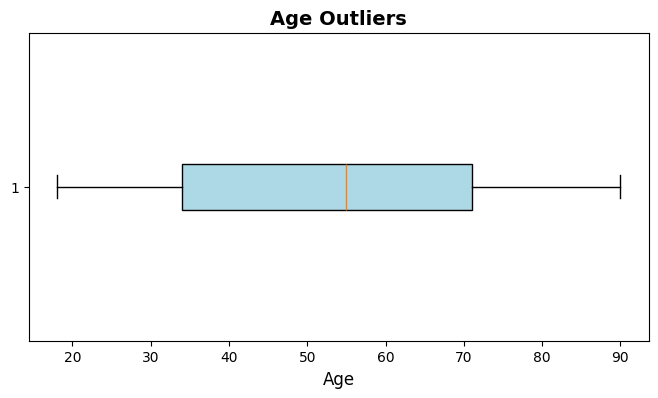

In [15]:
print("DATA PROFILING")

# 1. Minimum, Maximum, and Average Values
print("\n1. MIN, MAX, AND AVERAGE VALUES:")
display(df.describe()) # note here take screenshot for pdf report

# 2. Missing Values
print("\n2. MISSING VALUES:")
missing_vals = df.isnull().sum()
print(missing_vals[missing_vals > 0]) # Only prints columns that actually have missing data

# 3. Duplicates
print("\n3. DUPLICATES:")
total_duplicates = df.duplicated().sum()
print(f"Total fully duplicated rows in the dataset: {total_duplicates}")
print(f"Total duplicate Patient IDs: {df['patient_id'].duplicated().sum()}") # important to not have duplicate in ID

# 4. Invalid & Inconsistent Values (Strict Rules)
print("\n4. INVALID & INCONSISTENT VALUES:")
# 4.1 Count Strict Gender Errors
# STRICT RULE: We ONLY accept fully spelled out 'Male' and 'Female'.
# 'M', 'F', and numbers like '1' will all be flagged as formatting errors.
strict_genders = ['Male', 'Female']

# Count rows that do NOT match the strict rule ,ignoring empty rows
strict_gender_errors = (~df['gender'].isin(strict_genders) & df['gender'].notnull()).sum()
print(f"Total Gender errors (violates strict 'Male'/'Female' standard): {strict_gender_errors}")

# 4.2 Count Invalid Billing Amounts
# We try to force the column into pure numbers. If a row has currency symbols (£, $, €),
# Pandas will fail and turn it into a NaN (Not a Number).
numeric_billing = pd.to_numeric(df['billing_amount'], errors='coerce')

# Count how many rows failed the number conversion ,ignoring rows that were already empty
invalid_billing_count = (numeric_billing.isnull() & df['billing_amount'].notnull()).sum()
print(f"Total invalid Billing Amounts (contains text/symbols): {invalid_billing_count}")

# 5. Outliers Chart
print("\n5. OUTLIERS CHART (AGE):")
plt.figure(figsize=(8, 4))
plt.boxplot(df['age'].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Age Outliers', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.gca().set_facecolor('white')

# Display the chart
plt.show()

##-IMPLEMENT QUALITY CHECKS

Total Date errors (violates DD/MM/YYYY, impossible days, or future dates): 924
Quality Checks Completed on Data!


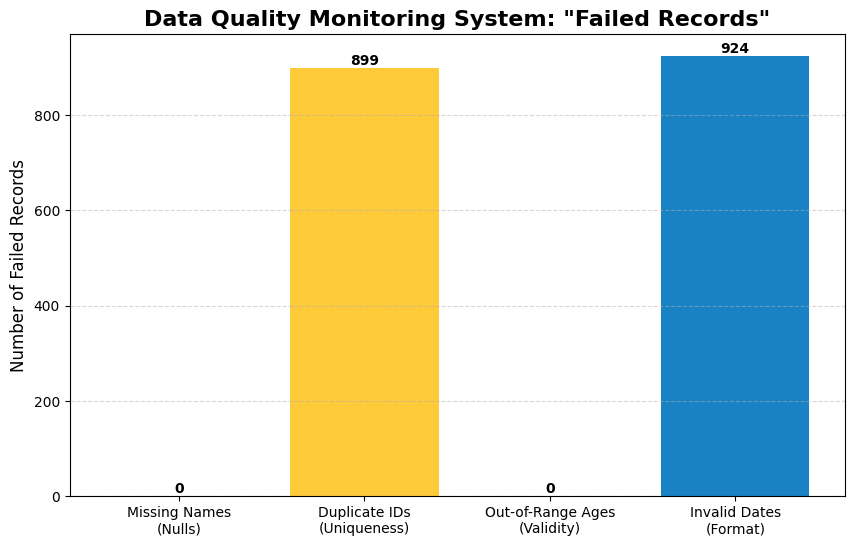

In [16]:
# IMPLEMENT QUALITY CHECKS

# 1. Null checks (Completeness)
# Count how many patient names are missing
null_failures = df['patient_name'].isnull().sum()

# 2. Duplicate checks (Uniqueness)
# Count how many patient IDs are exact duplicates
duplicate_failures = df['patient_id'].duplicated().sum()

# 3. Range checks (Validity)
# Count how many ages are impossible (less than 0 or greater than 120)
range_failures = ((df['age'] < 0) | (df['age'] > 120)).sum()


# 4 CONSISTENCY & VALIDITY (Strict Day/Month/Year Checks)

# Step 1: Force the text into actual Pandas Date objects.
# We demand the strict Day/Month/Year format ('%d/%m/%Y').
# If a date is Month/Day/Year, has a month > 12, or a day > 31, Pandas turns it into NaT (Not a Time).
converted_dates = pd.to_datetime(df['appointment_date'], format='%d/%m/%Y', errors='coerce')

# Step 2: Count the dates that failed the strict calendar/format test
# (Ignoring rows that were already completely empty)
invalid_calendar_dates = converted_dates.isnull() & df['appointment_date'].notnull()

# Step 3: Count the dates that are in the future (greater than today's exact date and time)
future_dates = converted_dates > pd.Timestamp.today()

# Step 4: Add both types of errors together to get your final failure count
date_failures = (invalid_calendar_dates | future_dates).sum()

print(f"Total Date errors (violates DD/MM/YYYY, impossible days, or future dates): {date_failures}")
print("Quality Checks Completed on Data!")

# 3. DISPLAY RESULTS USING CHARTS

# Group the failure counts for charting
failures = {
    'Missing Names\n(Nulls)': null_failures,
    'Duplicate IDs\n(Uniqueness)': duplicate_failures,
    'Out-of-Range Ages\n(Validity)': range_failures,
    'Invalid Dates\n(Format)': date_failures
}

# Create the Matplotlib Bar Chart
plt.figure(figsize=(10, 6))
bars = plt.bar(failures.keys(), failures.values(), color=['#FF595E', '#FFCA3A', '#8AC926', '#1982C4'])

# titles and labels
plt.title('Data Quality Monitoring System: "Failed Records"', fontsize=16, fontweight='bold')
plt.ylabel('Number of Failed Records', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add failure numbers on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontweight='bold')

# background white
plt.gca().set_facecolor('white')

plt.show()